In [1]:
import numpy as np
from IPython.display import Audio
import lightning as L
import sys
import pandas as pd
sys.path.append('../')

from lightning_scripts.jsinV3DataLoader_precombined_batched import jsinV3_precombined_all_signals
import importlib
import yaml
import torch
import os 
from pathlib import Path
from lightning_scripts.lightning_ssl_matched_speech_in_noise import LitAudioSSL
from robustness.audio_functions import audio_transforms as at
import h5py
import pickle
# from lightning_scripts.eval_jsin_transfer import SSLWordClassifier

%matplotlib inline
import matplotlib.pyplot as plt


In [21]:
## init config. Will be yaml eventually, but start as dict 
config_path = Path("model_configs/barlow_dualtask_resnet18_base_Matched.yaml")
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)
config['hparas']['batch_size'] = 2
config['num_workers'] = 0
TASK = "word"
LAYER = "avgpool" ## ckpt at this layerneeds to exist 
model_ckpt_dir = Path(f"model_checkpoints/{config_path.stem}/")
ckpt_path = model_ckpt_dir / "checkpoints/epoch=19-step=3600-best_train.ckpt"


In [22]:
module = LitAudioSSL.load_from_checkpoint(config=config, checkpoint_path=ckpt_path)
model = module.model.eval().cpu() #.cuda()

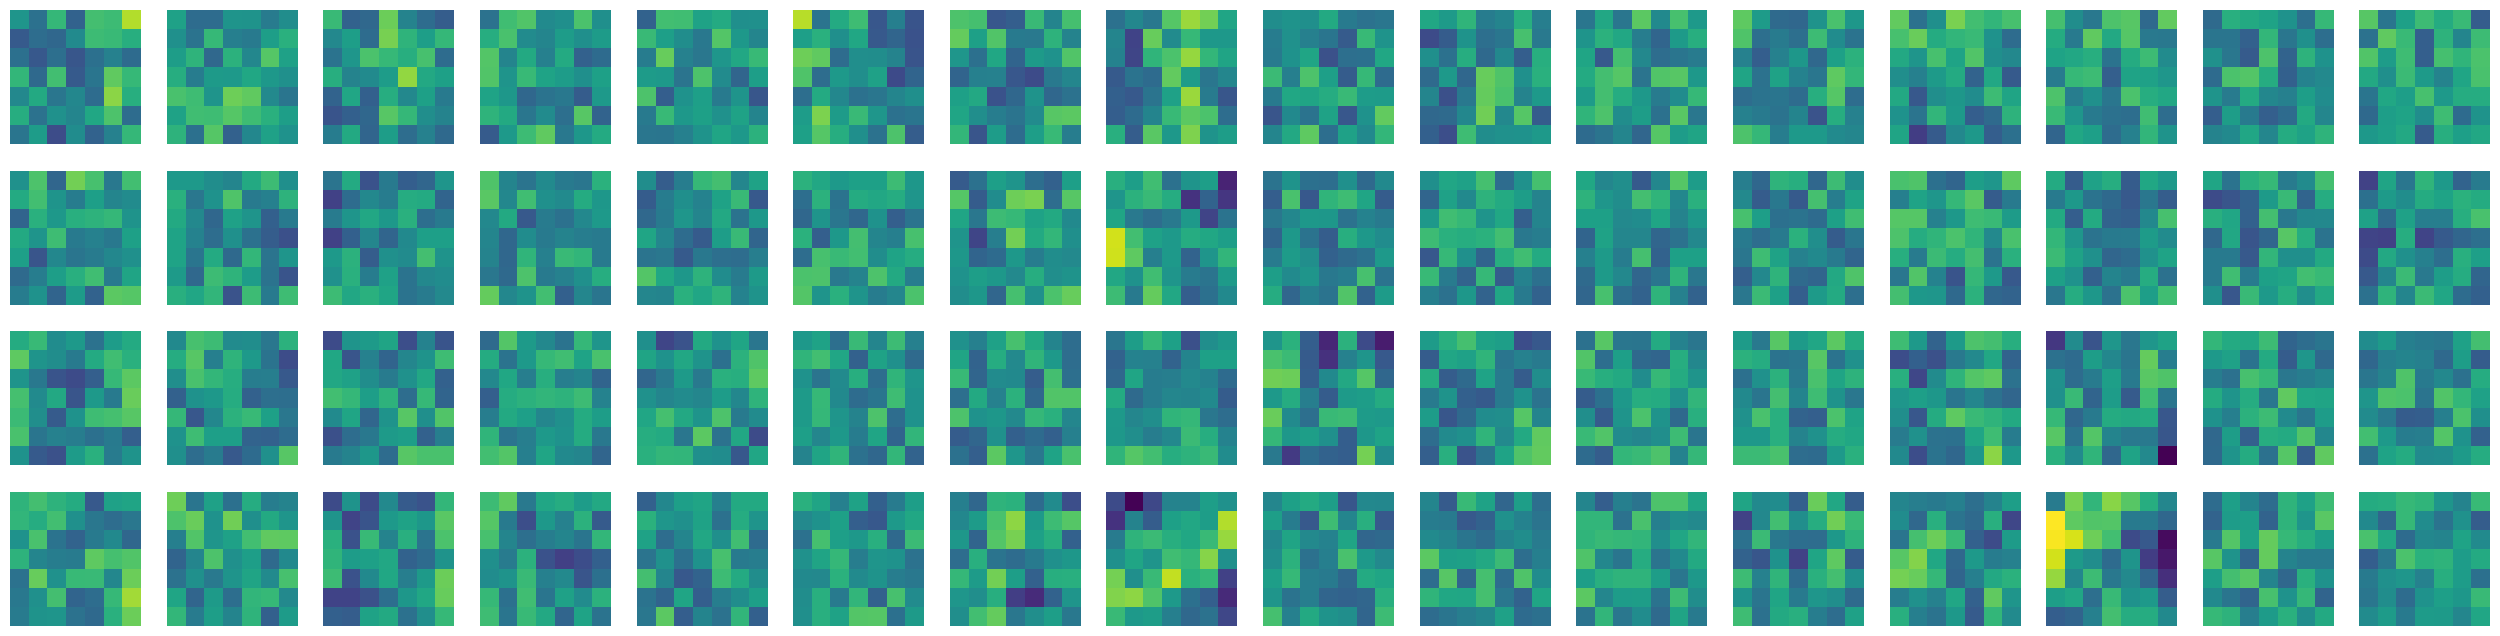

In [23]:
### Plot first layer weights 
conv1_kernels = model.model.f.conv1.weight.squeeze().detach()

aspect = 2
fig, axs = plt.subplots(4,16, figsize=(16*aspect, 4*aspect))
axs = axs.ravel()
for ix, kernel in enumerate(conv1_kernels):
    axs[ix].imshow(kernel, aspect='auto', vmin=conv1_kernels.min(), vmax=conv1_kernels.max(), interpolation="none")
    axs[ix].axis('off')


In [24]:
#### Check training and validation batches 

train_loader = module.train_dataloader()
val_loader = module.val_dataloader()

In [34]:
train_batch = next(iter(train_loader))
[spec_11, spec_12, spec_21, spec_22], [labels_11, labels_12, labels_21, labels_22] = train_batch
for combo in [spec_11, spec_12, spec_21, spec_22]:
    for example in combo:
        display(Audio(example, rate=20_000))

In [35]:
val_batch = next(iter(val_loader))
[spec_11, spec_12, spec_21, spec_22], [labels_11, labels_12, labels_21, labels_22] = val_batch
for combo in [spec_11, spec_12, spec_21, spec_22]:
    for example in combo:
        display(Audio(example, rate=20_000))

In [36]:
word_and_speaker_encodings = pickle.load(
    open("/mnt/home/igriffith/ceph/projects/cochdnn/robustness/audio_functions/word_and_speaker_encodings_jsinv3.pckl", "rb")
)
class_map = word_and_speaker_encodings["word_idx_to_word"]
talker_map = word_and_speaker_encodings["speaker_idx_to_speaker"]


In [37]:
## Get eval dataset 
########
# Get paths to uncombined h5
val_source_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/jsinV3BalancedProcessed/sr_20000/splits/valid_stackedDataframeHDF_n150_VJRUH4IEPDGPNH2JZMULSQKOWYNQ6KMM.pdh5'
# val_noise_h5 = '/mnt/home/jfeather/ceph/data/training_datasets_audio/audioset_dataframes/sr20000/cullLabels_silence/sr20000_balanced_train_segments_raw_exclude_speech_and_only_music_maxZerosPercent10.pdh5' 
val_dataframe_metadata = pd.read_hdf(val_source_h5)
val_source_files = h5py.File(val_source_h5, 'r')



In [38]:
### Def test transforms 
class CenterCropForeground(torch.nn.Module):
    """
    Center crops the foreground and background to make a shorter signal.
    """
    def __init__(self, crop_length):
        super(CenterCropForeground, self).__init__()
        self.crop_length = crop_length
        
    def forward(self, foreground_wav, background_wav):
        """
        Args:
            foreground_wav (torch.Tensor): the waveform that will be used as
                the foreground audio sample (usually speech)
        """
        if foreground_wav is not None:
            signal_size = foreground_wav.shape[-1]
            start_crop_center = int((signal_size-self.crop_length)/2)
            foreground_wav = foreground_wav[start_crop_center:start_crop_center+self.crop_length]
        if background_wav is not None:
            signal_size = background_wav.shape[-1]
            start_crop_center = int((signal_size-self.crop_length)/2)
            background_wav = background_wav[start_crop_center:start_crop_center+self.crop_length]
        return foreground_wav, background_wav
    
transforms = at.AudioCompose([
                at.AudioToTensor(),
                CenterCropForeground(40000),
                at.DBSPLNormalizeForegroundAndBackground(60),
                at.UnsqueezeAudio(dim=0), # dim=0 here so batches of audio from dataloader will be (Batch, 1, Time)
                at.UnsqueezeAudio(dim=0), # dim=0 here so batches of audio from dataloader will be (Batch, 1, Time)
            ])

In [ ]:
## dummy pass data through model 
n_to_run = 10#00
word_scores = np.zeros(n_to_run)
speaker_scores = np.zeros(n_to_run)
with torch.no_grad():
    for i in range(n_to_run):
        word_int, speaker_int = val_dataframe_metadata.loc[i, ['word_int', 'speaker_int']] # .item()
        signal = val_source_files['ndarray_data']['signal'][i]
    
        signal_tensor = transforms(signal, None)[0]#.cuda().float()
        print(f"Word: {class_map[word_int]} Speaker: {talker_map[speaker_int]}")
        display(Audio(signal_tensor.squeeze(), rate=20_000))
        print(f"")

#         _, _, logits = model(signal_tensor)
#         word_pred = logits['signal/word_int'].softmax(-1).argmax(-1)
#         speaker_pred = logits['signal/speaker_int'].softmax(-1).argmax(-1)
#         # print(f"Words \n True: {class_map[word_int]} Pred: {class_map[word_pred.item()]}")
#         # print(f"Speakers \n True: {talker_map[speaker_int]} Pred: {talker_map[speaker_pred.item()]}")
#         word_scores[i] = int(word_int == word_pred)
#         speaker_scores[i] = int(speaker_int == speaker_pred)
#         # display(Audio(signal, rate=20_000))
# print("Word accuracy: ", word_scores.mean())
# print("Speaker accuracy: ", speaker_scores.mean())


Word: caused Speaker: lily5lace



Word: joined Speaker: pinangjawa



Word: added Speaker: gallen89



Word: problem Speaker: silas-s-brown



Word: calls Speaker: viktor-o-ledenyov



Word: medical Speaker: 46y



Word: elements Speaker: anaxial



Word: million Speaker: 4ag



Word: required Speaker: warpig1994



Word: region Speaker: cupobeans


In [131]:
logits.keys()

dict_keys(['signal/word_int', 'signal/speaker_int', 'noise/labels_int'])

In [ ]:
#### Dev ran